# Chapter 2 — Value-based RL
*Reinforcement Learning: An Overview*, Murphy (arXiv:2412.05265v5) — §2

Bellman equations · Value iteration · Policy iteration · TD learning · SARSA · Q-learning

In [1]:
%pip install -q numpy matplotlib
print('ready')

/Users/ppcc/Desktop/Reinforcement-Learning/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.
ready


## 2.1 Bellman Equations

State-value function:
$$V^\pi(s)=\sum_a\pi(a\mid s)\Bigl[r(s,a)+\gamma\sum_{s'}p(s'\mid s,a)V^\pi(s')\Bigr]$$

Optimality condition:
$$V^*(s)=\max_a\Bigl[r(s,a)+\gamma\sum_{s'}p(s'\mid s,a)V^*(s')\Bigr]$$

VI converged: 2063 iters


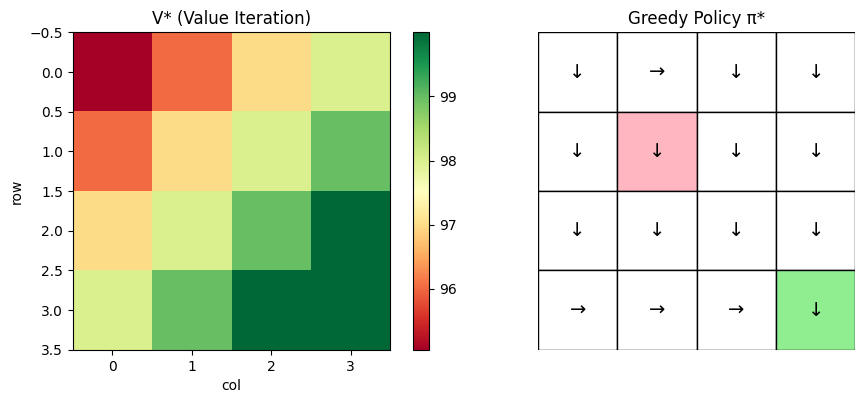

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class GridWorld:
    SIZE = 4; GOAL, HOLE = (3,3), (1,1)
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]
    def __init__(self, gamma=0.99): self.gamma=gamma; self.pos=(0,0)
    def reset(self): self.pos=(0,0); return self.idx(self.pos)
    def step(self, a):
        r,c=self.pos; dr,dc=self.MOVES[a]
        self.pos=(max(0,min(self.SIZE-1,r+dr)),max(0,min(self.SIZE-1,c+dc)))
        if self.pos==self.GOAL: return self.idx(self.pos), 1.0,True
        if self.pos==self.HOLE: return self.idx(self.pos),-1.0,True
        return self.idx(self.pos),-0.01,False
    def step_from(self,pos,a):
        old=self.pos; self.pos=pos; s,r,d=self.step(a); res=(self.pos,r,d); self.pos=old; return res
    def idx(self,pos): return pos[0]*self.SIZE+pos[1]
    def pos_of(self,i): return (i//self.SIZE,i%self.SIZE)
    def n_states(self): return self.SIZE**2
    def n_actions(self): return 4

env = GridWorld()
S,A = env.n_states(), env.n_actions()
T = np.zeros((S,A,S)); R = np.zeros((S,A))
for s in range(S):
    for a in range(A):
        ns_pos,r,_ = env.step_from(env.pos_of(s),a)
        T[s,a,env.idx(ns_pos)] = 1.0; R[s,a] = r

def value_iteration(T, R, gamma, tol=1e-9):
    S,A,_ = T.shape; V = np.zeros(S)
    for i in range(5000):
        Q = R + gamma*(T*V[None,None,:]).sum(-1)
        V_new = Q.max(-1)
        if np.max(np.abs(V_new-V)) < tol:
            print(f"VI converged: {i+1} iters"); break
        V = V_new
    return V, Q.argmax(-1), Q

V_star, pi_star, Q_star = value_iteration(T, R, env.gamma)

ARROWS = ["↑","↓","←","→"]
fig, axes = plt.subplots(1, 2, figsize=(10,4))

im = axes[0].imshow(V_star.reshape(4,4), cmap="RdYlGn", origin="upper")
plt.colorbar(im, ax=axes[0]); axes[0].set_title("V* (Value Iteration)")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")

axes[1].set_xlim(0,4); axes[1].set_ylim(0,4); axes[1].set_aspect("equal")
axes[1].set_title("Greedy Policy π*"); axes[1].axis("off")
for s in range(S):
    r,c = env.pos_of(s)
    col = "#90EE90" if (r,c)==(3,3) else "#FFB6C1" if (r,c)==(1,1) else "white"
    axes[1].add_patch(patches.Rectangle((c,3-r),1,1,ec="black",fc=col))
    axes[1].text(c+.5, 3.5-r, ARROWS[pi_star[s]], ha="center", va="center", fontsize=14)

plt.tight_layout(); plt.show()


## 2.2 Policy Iteration

1. **Policy Evaluation** — iterate $V^\pi$ until convergence
2. **Policy Improvement** — $\pi'(s)=\arg\max_a Q^\pi(s,a)$

Guaranteed monotone improvement; converges in finite steps.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class GridWorld:
    SIZE = 4; GOAL, HOLE = (3,3), (1,1)
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]
    def __init__(self, gamma=0.99): self.gamma=gamma; self.pos=(0,0)
    def reset(self): self.pos=(0,0); return self.idx(self.pos)
    def step(self, a):
        r,c=self.pos; dr,dc=self.MOVES[a]
        self.pos=(max(0,min(self.SIZE-1,r+dr)),max(0,min(self.SIZE-1,c+dc)))
        if self.pos==self.GOAL: return self.idx(self.pos), 1.0,True
        if self.pos==self.HOLE: return self.idx(self.pos),-1.0,True
        return self.idx(self.pos),-0.01,False
    def step_from(self,pos,a):
        old=self.pos; self.pos=pos; s,r,d=self.step(a); res=(self.pos,r,d); self.pos=old; return res
    def idx(self,pos): return pos[0]*self.SIZE+pos[1]
    def pos_of(self,i): return (i//self.SIZE,i%self.SIZE)
    def n_states(self): return self.SIZE**2
    def n_actions(self): return 4

env = GridWorld()
S,A = env.n_states(), env.n_actions()
T = np.zeros((S,A,S)); R = np.zeros((S,A))
for s in range(S):
    for a in range(A):
        ns_pos,r,_ = env.step_from(env.pos_of(s),a)
        T[s,a,env.idx(ns_pos)] = 1.0; R[s,a] = r

def policy_eval(pi, T, R, gamma, tol=1e-9):
    S = T.shape[0]; V = np.zeros(S)
    for _ in range(10000):
        V_new = np.array([R[s,pi[s]]+gamma*T[s,pi[s]]@V for s in range(S)])
        if np.max(np.abs(V_new-V)) < tol: break
        V = V_new
    return V

def policy_iteration(T, R, gamma):
    S = T.shape[0]; pi = np.zeros(S,dtype=int)
    for i in range(1000):
        V = policy_eval(pi, T, R, gamma)
        Q = R + gamma*(T*V[None,None,:]).sum(-1)
        pi_new = Q.argmax(-1)
        if np.all(pi_new==pi): print(f"PI converged: {i+1} iters"); break
        pi = pi_new
    return V, pi

V_pi, pi_pi = policy_iteration(T, R, env.gamma)
V_vi, pi_vi, _ = value_iteration(T, R, env.gamma)
print(f"max|V_VI - V_PI| = {np.max(np.abs(V_vi-V_pi)):.2e}")
print(f"Policies match:    {np.all(pi_vi==pi_pi)}")


PI converged: 6 iters
VI converged: 2063 iters
max|V_VI - V_PI| = 0.00e+00
Policies match:    True


## 2.3 TD Learning: SARSA (on-policy)

$$Q(s,a)\leftarrow Q(s,a)+\alpha\bigl[r+\gamma Q(s',a')-Q(s,a)\bigr]$$

$a'$ is chosen by the **same** policy → on-policy.

## 2.4 Q-Learning (off-policy)

$$Q(s,a)\leftarrow Q(s,a)+\alpha\bigl[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\bigr]$$

Bootstrap with greedy max → converges to $Q^*$ regardless of behaviour policy.

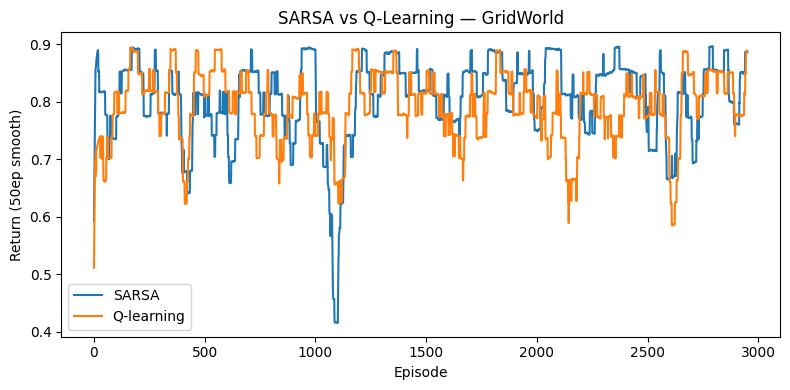

VI converged: 2063 iters
Optimal V*(start) = 95.050
SARSA      last-500 mean = 0.799
Q-learning last-500 mean = 0.802


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class GridWorld:
    SIZE = 4; GOAL, HOLE = (3,3), (1,1)
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]
    def __init__(self, gamma=0.99): self.gamma=gamma; self.pos=(0,0)
    def reset(self): self.pos=(0,0); return self.idx(self.pos)
    def step(self, a):
        r,c=self.pos; dr,dc=self.MOVES[a]
        self.pos=(max(0,min(self.SIZE-1,r+dr)),max(0,min(self.SIZE-1,c+dc)))
        if self.pos==self.GOAL: return self.idx(self.pos), 1.0,True
        if self.pos==self.HOLE: return self.idx(self.pos),-1.0,True
        return self.idx(self.pos),-0.01,False
    def step_from(self,pos,a):
        old=self.pos; self.pos=pos; s,r,d=self.step(a); res=(self.pos,r,d); self.pos=old; return res
    def idx(self,pos): return pos[0]*self.SIZE+pos[1]
    def pos_of(self,i): return (i//self.SIZE,i%self.SIZE)
    def n_states(self): return self.SIZE**2
    def n_actions(self): return 4

env = GridWorld()
S,A = env.n_states(), env.n_actions()
T = np.zeros((S,A,S)); R = np.zeros((S,A))
for s in range(S):
    for a in range(A):
        ns_pos,r,_ = env.step_from(env.pos_of(s),a)
        T[s,a,env.idx(ns_pos)] = 1.0; R[s,a] = r

def eps_greedy(Q, s, eps):
    return np.random.randint(Q.shape[1]) if np.random.rand()<eps else Q[s].argmax()

def sarsa(n_ep=3000, alpha=0.1, gamma=0.99, eps=0.1):
    Q = np.zeros((S,A)); returns=[]
    for _ in range(n_ep):
        s=env.reset(); a=eps_greedy(Q,s,eps); G=0; gt=1
        for _ in range(200):
            ns,r,done=env.step(a); na=eps_greedy(Q,ns,eps)
            Q[s,a]+=alpha*(r+gamma*Q[ns,na]-Q[s,a])
            G+=gt*r; gt*=gamma; s,a=ns,na
            if done: break
        returns.append(G)
    return Q, returns

def qlearning(n_ep=3000, alpha=0.1, gamma=0.99, eps=0.1):
    Q = np.zeros((S,A)); returns=[]
    for _ in range(n_ep):
        s=env.reset(); G=0; gt=1
        for _ in range(200):
            a=eps_greedy(Q,s,eps); ns,r,done=env.step(a)
            Q[s,a]+=alpha*(r+gamma*Q[ns].max()-Q[s,a])
            G+=gt*r; gt*=gamma; s=ns
            if done: break
        returns.append(G)
    return Q, returns

_, ret_sarsa = sarsa()
_, ret_ql    = qlearning()
smooth = lambda x, w=50: np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(8,4))
plt.plot(smooth(ret_sarsa), label="SARSA")
plt.plot(smooth(ret_ql),    label="Q-learning")
plt.xlabel("Episode"); plt.ylabel("Return (50ep smooth)")
plt.title("SARSA vs Q-Learning — GridWorld"); plt.legend(); plt.tight_layout(); plt.show()

V_vi, _, _ = value_iteration(T, R, env.gamma)
print(f"Optimal V*(start) = {V_vi[0]:.3f}")
print(f"SARSA      last-500 mean = {np.mean(ret_sarsa[-500:]):.3f}")
print(f"Q-learning last-500 mean = {np.mean(ret_ql[-500:]):.3f}")
